In [2]:
import os
import pandas as pd

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))

file_path = os.path.join(BASE_DIR, "data/raw/reviews_raw.csv")

df = pd.read_csv(file_path)

df.head()
df.shape

(1800, 5)

In [3]:
df = df.drop_duplicates()

In [4]:
df = df.drop_duplicates(subset=["review", "bank"])

In [5]:
df = df.dropna(subset=["review", "rating"])

In [6]:
df["date"] = pd.to_datetime(df["date"]).dt.date

In [7]:
df["review"] = df["review"].astype(str).str.strip()

In [8]:
print(df.isnull().sum())
print(df.groupby("bank").size())

review    0
rating    0
date      0
bank      0
source    0
dtype: int64
bank
BOA       496
CBE       507
DASHEN    499
dtype: int64


In [9]:
df.to_csv("../data/processed/reviews_clean.csv", index=False)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/reviews_with_sentiment.csv")
print(df.columns)

Index(['review', 'rating', 'date', 'bank', 'source', 'sentiment_label',
       'sentiment_score'],
      dtype='str')


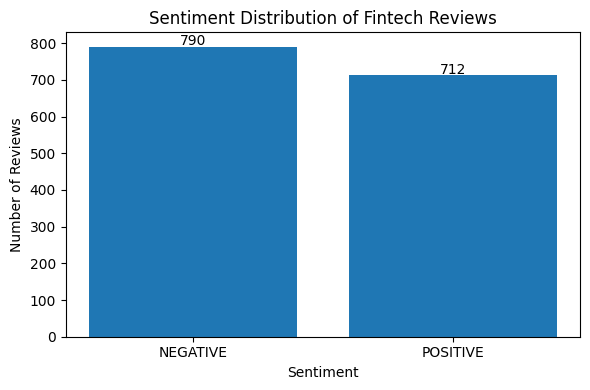

In [14]:


# Count sentiment labels
sentiment_counts = df["sentiment_label"].value_counts()

# Convert to DataFrame
sentiment_df = sentiment_counts.reset_index()
sentiment_df.columns = ["sentiment", "count"]

# Plot
plt.figure(figsize=(6,4))
plt.bar(sentiment_df["sentiment"], sentiment_df["count"])

plt.title("Sentiment Distribution of Fintech Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Add value labels
for i, v in enumerate(sentiment_df["count"]):
    plt.text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()